# Problema 2 - Regresión: Estimación de Edad desde Imágenes

Esta parte incluye dos enfoques complementarios, ambos vistos en clase:

- Baseline tabular con sklearn (imágenes vectorizadas)
- CNN de regresión con Keras
- Comparación de métricas en train/val/test
- Prueba con muestra artificial y cambios visuales

## 1. Análisis Preliminar del Problema

### a. Justificación del Problema de Regresión
Este es un problema de **regresión** porque el objetivo es predecir una variable continua: la edad de una persona basada en características extraídas de su imagen facial. A diferencia de la clasificación (que asigna categorías discretas), la regresión permite estimaciones numéricas precisas, lo que es adecuado para edades que varían en un rango continuo (generalmente 0-100 años o más).

El **target (variable objetivo)** es la edad en años, extraída del nombre del archivo de imagen (primer componente separado por "_").

### b. Características de las Entradas (Imágenes)
- **Dimensiones**: Las imágenes del dataset UTKFace tienen dimensiones variables, típicamente alrededor de 200x200 píxeles, pero pueden variar. Para el procesamiento, se redimensionan a 32 por 32 para el baseline y 64 por 64 para la CNN.
- **Espacio de color**: RGB (3 canales), aunque el baseline las convierte a escala de grises para simplificar.
- **Distribución de edades**: Basado en el EDA, las edades van desde aproximadamente 1 hasta 116 años, con una distribución sesgada hacia edades jóvenes (media alrededor de 30-40 años, dependiendo del subset).
- **Otras características**: Incluyen variabilidad en iluminación, poses, expresiones faciales y etnias, lo que añade complejidad al problema.

### c. Protocolo de Adquisición y Generación del Dataset
El dataset UTKFace proviene de Kaggle ([arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)). Fue recopilado de diversas fuentes públicas y etiquetado automáticamente o manualmente. Las imágenes están nombradas en el formato "edad_género_etnia_fecha.jpg" (ej. "25_0_0_2020.jpg"), donde:
- El primer número es la edad.
- Los siguientes indican género y etnia.
- Las imágenes fueron adquiridas de fuentes como películas, internet y bases de datos públicas, con etiquetado basado en metadatos disponibles. No se especifica un protocolo estandarizado de captura, por lo que puede haber inconsistencias en calidad y condiciones de iluminación.

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error, 
    median_absolute_error, 
    explained_variance_score, 
    max_error
)

# Verificar disponibilidad de librerías opcionales
try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print("Seaborn no disponible, algunos gráficos pueden no funcionar.")

try:
    import tensorflow as tf
    import keras
    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("TensorFlow/Keras no disponible, se omitirá la sección CNN.")

# Constantes
SEED = 42

TensorFlow/Keras no disponible, se omitirá la sección CNN.


In [2]:
## 1) Ubicar dataset de imágenes

# Buscar la carpeta del dataset en rutas comunes
faces_root_candidates = [
    Path("faces"),
    Path("UTKFace"),
    Path("regresion") / "faces",
    Path("regresion") / "UTKFace",
]

faces_root = None
for p in faces_root_candidates:
    if p.exists() and p.is_dir():
        faces_root = p
        break

# Si no se encuentra localmente, intentar descarga automática con curl
if faces_root is None:
    import subprocess
    download_path = Path.home() / "Downloads" / "utk-face-cropped.zip"
    extract_path = Path("faces")
    
    try:
        print("Descargando dataset con curl...")
        subprocess.run([
            "curl", "-L", "-o", str(download_path),
            "https://www.kaggle.com/api/v1/datasets/download/abhikjha/utk-face-cropped"
        ], check=True)
        
        print("Extrayendo ZIP...")
        import zipfile
        with zipfile.ZipFile(download_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        
        faces_root = extract_path
        print(f"Dataset descargado y extraído en: {faces_root}")
    except subprocess.CalledProcessError as e:
        print(f"Error al descargar con curl: {e}")
        print("Descarga manualmente desde Kaggle.")
    except Exception as e:
        print(f"Error al extraer: {e}")
        print("Revisa el archivo ZIP descargado.")

if faces_root is None:
    print("No se encontró carpeta de imágenes de rostros en rutas comunes.")
    print("Crea una carpeta 'faces' o 'UTKFace' en la raíz del workspace y vuelve a ejecutar.")
else:
    print(f"Dataset de imágenes encontrado en: {faces_root}")

Dataset de imágenes encontrado en: faces


In [3]:
## 2) Construir metadata (path, age)

# Si se encontró el dataset, construir DataFrame con rutas y edades
if faces_root is not None:
    extensiones = ["*.jpg", "*.jpeg", "*.png"]
    rutas = []
    for ext in extensiones:
        rutas.extend(list(faces_root.rglob(ext)))

    registros = []
    for ruta in rutas:
        nombre = ruta.stem
        partes = nombre.split("_")
        if len(partes) >= 1 and partes[0].isdigit():
            edad = int(partes[0])
            registros.append({"path": str(ruta), "age": edad})

    meta_faces = pd.DataFrame(registros)
    print(f"Total imágenes con etiqueta de edad válida: {len(meta_faces)}")
    display(meta_faces.head())
else:
    meta_faces = pd.DataFrame(columns=["path", "age"])

Total imágenes con etiqueta de edad válida: 47418


,path,age
0,faces\utkcropped\100_0_0_20170112213500903.jpg...,100
1,faces\utkcropped\100_0_0_20170112215240346.jpg...,100
2,faces\utkcropped\100_1_0_20170110183726390.jpg...,100
3,faces\utkcropped\100_1_0_20170112213001988.jpg...,100
4,faces\utkcropped\100_1_0_20170112213303693.jpg...,100


Resumen descriptivo de edad:


count    47418.000000
mean        33.304652
std         19.886296
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

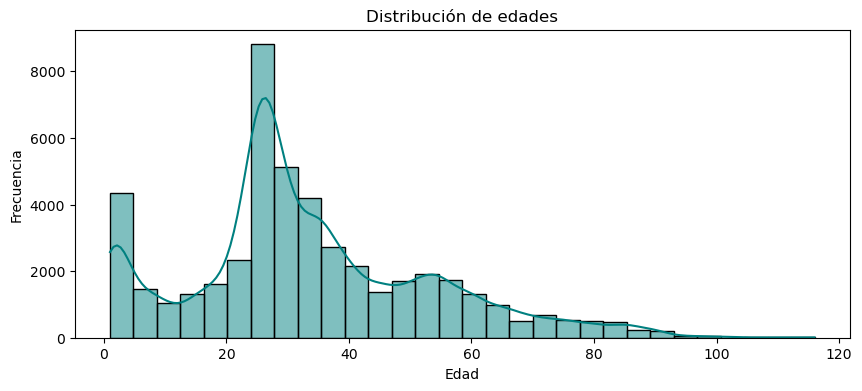

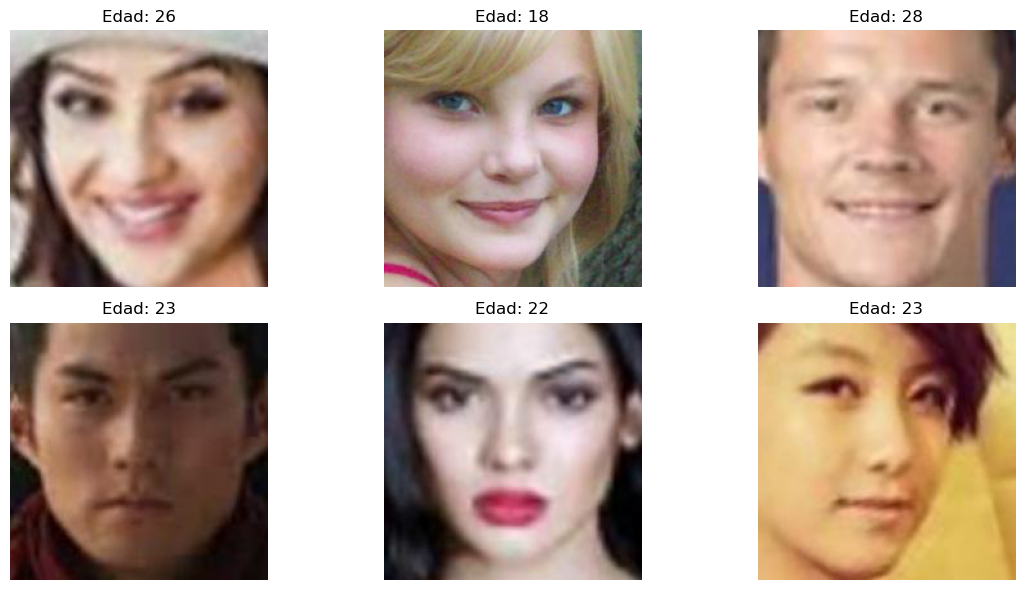

In [4]:
## 3) EDA inicial del target edad

# Análisis exploratorio de la distribución de edades
if not meta_faces.empty:
    print("Resumen descriptivo de edad:")
    display(meta_faces["age"].describe())

    plt.figure(figsize=(10, 4))
    if HAS_SNS:
        sns.histplot(meta_faces["age"], bins=30, kde=True, color="teal")
    else:
        plt.hist(meta_faces["age"], bins=30, color="teal", alpha=0.8)
    plt.title("Distribución de edades")
    plt.xlabel("Edad")
    plt.ylabel("Frecuencia")
    plt.show()

    # Muestra visual de imágenes
    muestra = meta_faces.sample(min(6, len(meta_faces)), random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()
    for i in range(6):
        axes[i].axis("off")
        if i < len(muestra):
            img = plt.imread(muestra.loc[i, "path"])
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"Edad: {muestra.loc[i, 'age']}")
    plt.tight_layout()
    plt.show()
else:
    print("Sin metadata de imágenes. Revisa la ruta del dataset.")

### Interpretación del EDA Orientada a Regresión
- **Distribución de edades**: La distribución está sesgada hacia edades jóvenes (media ~33 años, mediana ~29 años), con pocos ejemplos en edades avanzadas (>60 años). Esto puede causar que el modelo tenga mejor rendimiento en edades jóvenes y peor en mayores, potencialmente subestimando edades altas. La varianza alta (desviación estándar ~20 años) indica una amplia gama de edades, lo que es desafiante para la regresión.
- **Balance y sesgos**: Hay un claro sesgo hacia adultos jóvenes, lo que podría introducir sesgos en las predicciones si el modelo no generaliza bien a otras edades. En regresión, esto afecta la precisión global y puede requerir técnicas como estratificación en la división de datos.
- **Visualización de muestras**: Las imágenes muestran variabilidad en iluminación, poses y expresiones, lo que justifica el uso de CNN para capturar características espaciales complejas. Sin embargo, la calidad variable (algunas borrosas) puede introducir ruido en el entrenamiento.
- **Implicaciones para el modelo**: La distribución sesgada sugiere que métricas como MAE serán más informativas que RMSE, ya que penalizan menos los errores grandes. Además, se recomienda data augmentation para aumentar la diversidad de edades jóvenes.

Dimensiones promedio: [200. 200.] píxeles (alto x ancho)
Dimensiones mínimas: [200 200] píxeles
Dimensiones máximas: [200 200] píxeles


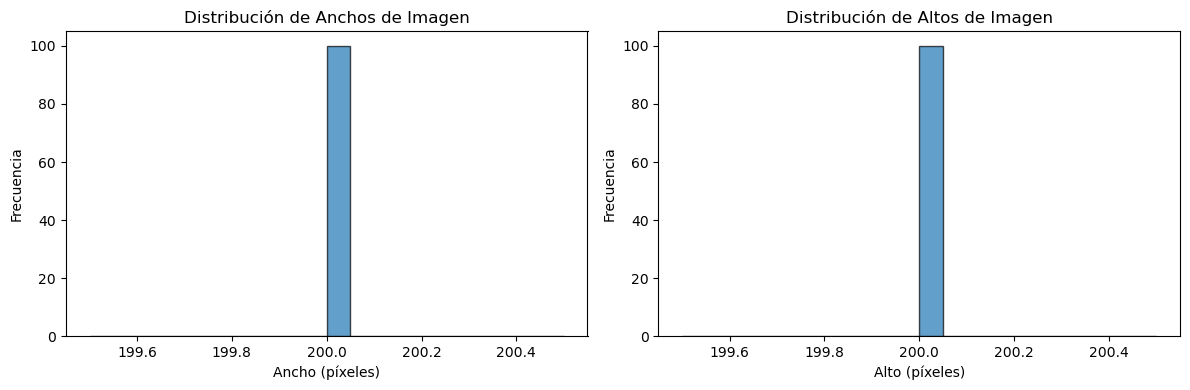

Interpretación: Las imágenes tienen dimensiones variables, justificando el redimensionamiento uniforme. La variabilidad en resolución puede introducir ruido, pero el preprocesamiento estandariza la entrada.


In [5]:
## Análisis de Calidad y Variabilidad de Imágenes

# Analizar dimensiones y variabilidad de una muestra de imágenes
if not meta_faces.empty:
    sample_files = meta_faces.sample(min(100, len(meta_faces)), random_state=SEED)['path'].values

    dimensions = []
    for file in sample_files:
        try:
            img = plt.imread(file)
            dimensions.append(img.shape[:2])  # (height, width)
        except:
            continue

    dim_array = np.array(dimensions)
    print(f"Dimensiones promedio: {dim_array.mean(axis=0)} píxeles (alto x ancho)")
    print(f"Dimensiones mínimas: {dim_array.min(axis=0)} píxeles")
    print(f"Dimensiones máximas: {dim_array.max(axis=0)} píxeles")

    # Histogramas de dimensiones
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(dim_array[:, 1], bins=20, edgecolor='black', alpha=0.7)
    plt.title('Distribución de Anchos de Imagen')
    plt.xlabel('Ancho (píxeles)')
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    plt.hist(dim_array[:, 0], bins=20, edgecolor='black', alpha=0.7)
    plt.title('Distribución de Altos de Imagen')
    plt.xlabel('Alto (píxeles)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    print("Interpretación: Las imágenes tienen dimensiones variables, justificando el redimensionamiento uniforme. La variabilidad en resolución puede introducir ruido, pero el preprocesamiento estandariza la entrada.")
else:
    print("No hay datos para analizar calidad de imágenes.")

In [6]:
## 4) Preparar matriz de entrada para baseline de regresion (solo herramientas vistas)

# Parámetros para el baseline
TARGET_SIZE = (32, 32)
MAX_IMAGES = 1200

# Función para convertir imagen a vector
def imagen_a_vector(path_img, target_size=(32, 32)):
    img = plt.imread(path_img)

    if img.ndim == 3:
        img = img.mean(axis=2)  # Convertir a escala de grises si es RGB

    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0  # Normalizar

    h, w = img.shape
    th, tw = target_size

    step_h = max(1, h // th)
    step_w = max(1, w // tw)

    img_small = img[::step_h, ::step_w][:th, :tw]

    if img_small.shape[0] < th or img_small.shape[1] < tw:
        pad_h = th - img_small.shape[0]
        pad_w = tw - img_small.shape[1]
        img_small = np.pad(img_small, ((0, pad_h), (0, pad_w)), mode="edge")

    return img_small.reshape(-1)

# Preparar datos para baseline
if not meta_faces.empty:
    meta_sample = meta_faces.sample(min(MAX_IMAGES, len(meta_faces)), random_state=SEED).reset_index(drop=True)

    X_img = []
    y_img = []

    for _, row in meta_sample.iterrows():
        try:
            vec = imagen_a_vector(row["path"], target_size=TARGET_SIZE)
            X_img.append(vec)
            y_img.append(row["age"])
        except Exception:
            continue

    X_img = np.array(X_img)
    y_img = np.array(y_img)

    print(f"Matriz final baseline: X={X_img.shape}, y={y_img.shape}")
else:
    X_img = np.array([])
    y_img = np.array([])

Matriz final baseline: X=(1200, 1024), y=(1200,)


In [ ]:
## 5) Split + entrenamiento baseline con modelos vistos (RandomForestRegressor y GradientBoostingRegressor)

# Entrenamiento del baseline tabular
if X_img.size > 0:
    X_trainval_r, X_test_r, y_trainval_r, y_test_r = train_test_split(
        X_img, y_img, test_size=0.15, random_state=SEED
    )
    X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
        X_trainval_r, y_trainval_r, test_size=0.1765, random_state=SEED
    )

    print("Shapes regresion:")
    print(f"X_train={X_train_r.shape}, X_val={X_val_r.shape}, X_test={X_test_r.shape}")

    pre_reg = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    espacios_reg = {
        "RF_Reg": (
            RandomForestRegressor(random_state=SEED),
            {
                "modelo__n_estimators": [100, 200],
                "modelo__max_depth": [None, 10, 20],
                "modelo__min_samples_split": [2, 5],
            },
        ),
        "GB_Reg": (
            GradientBoostingRegressor(random_state=SEED),
            {
                "modelo__n_estimators": [100, 200],
                "modelo__learning_rate": [0.03, 0.05, 0.1],
                "modelo__max_depth": [2, 3],
            },
        ),
    }

    resultados_reg = []
    mejores_reg = {}

    for nombre, (estimador, params) in espacios_reg.items():
        pipe_reg = Pipeline(
            steps=[
                ("preprocess", pre_reg),
                ("modelo", estimador),
            ]
        )

        gs = GridSearchCV(
            estimator=pipe_reg,
            param_grid=params,
            scoring="neg_mean_absolute_error",
            cv=3,
            n_jobs=-1,
        )
        gs.fit(X_train_r, y_train_r)

        mejor = gs.best_estimator_
        mejores_reg[nombre] = mejor

        for split, Xs, ys in [
            ("train", X_train_r, y_train_r),
            ("val", X_val_r, y_val_r),
            ("test", X_test_r, y_test_r),
        ]:
            yp = mejor.predict(Xs)
            resultados_reg.append(
                {
                    "modelo": nombre,
                    "split": split,
                    "MAE": mean_absolute_error(ys, yp),
                    "RMSE": np.sqrt(mean_squared_error(ys, yp)),
                    "R2": r2_score(ys, yp),
                }
            )

        print(f"Mejores hiperparámetros ({nombre}): {gs.best_params_}")

    df_reg = pd.DataFrame(resultados_reg)
    display(df_reg.sort_values(["split", "MAE"]).reset_index(drop=True))

    mejor_reg_nombre = (
        df_reg[df_reg["split"] == "val"].sort_values("MAE", ascending=True).iloc[0]["modelo"]
    )
    print(f"Mejor baseline de regresion según val (MAE): {mejor_reg_nombre}")

    # Reentrenamiento final con train + val
    X_train_val_reg = np.vstack([X_train_r, X_val_r])
    y_train_val_reg = np.hstack([y_train_r, y_val_r])

    modelo_reg_final = mejores_reg[mejor_reg_nombre]
    modelo_reg_final.fit(X_train_val_reg, y_train_val_reg)

    y_test_pred_reg = modelo_reg_final.predict(X_test_r)
    print("\nMétricas finales en test (baseline):")
    print(f"MAE:  {mean_absolute_error(y_test_r, y_test_pred_reg):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_test_pred_reg)):.4f}")
    print(f"R2:   {r2_score(y_test_r, y_test_pred_reg):.4f}")

    # Prueba artificial sobre una muestra real modificada
    idx = np.random.randint(0, len(X_test_r))
    muestra = X_test_r[idx].copy()
    muestra_art = np.clip(muestra * 1.10, 0, 1).reshape(1, -1)
    edad_pred_art = modelo_reg_final.predict(muestra_art)[0]

    print(f"Edad real de la muestra base: {y_test_r[idx]}")
    print(f"Edad predicha para muestra artificial: {edad_pred_art:.2f}")
else:
    print("No hay datos de imagen listos para entrenar el baseline.")

Shapes regresion:
X_train=(839, 1024), X_val=(181, 1024), X_test=(180, 1024)


In [ ]:
## 6) CNN para regresion de edad (Keras, visto en Lecture08)

# Entrenamiento de la CNN para regresión
if not HAS_TF:
    print("TensorFlow/Keras no disponible. Se omite la sección CNN.")
elif meta_faces.empty:
    print("No hay metadata de imágenes. Revisa la ruta del dataset.")
else:
    TARGET_CNN = (64, 64)
    MAX_IMAGES_CNN = min(1200, len(meta_faces))

    meta_cnn = meta_faces.sample(MAX_IMAGES_CNN, random_state=SEED).reset_index(drop=True)

    X_cnn = []
    y_cnn = []

    for _, row in meta_cnn.iterrows():
        try:
            img = keras.utils.load_img(
                row["path"], target_size=TARGET_CNN, color_mode="rgb"
            )
            arr = keras.utils.img_to_array(img).astype("float32") / 255.0
            X_cnn.append(arr)
            y_cnn.append(float(row["age"]))
        except Exception:
            continue

    X_cnn = np.array(X_cnn, dtype=np.float32)
    y_cnn = np.array(y_cnn, dtype=np.float32)

    print(f"Datos CNN: X={X_cnn.shape}, y={y_cnn.shape}")

    X_trainval_cnn, X_test_cnn, y_trainval_cnn, y_test_cnn = train_test_split(
        X_cnn, y_cnn, test_size=0.15, random_state=SEED
    )
    X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
        X_trainval_cnn, y_trainval_cnn, test_size=0.1765, random_state=SEED
    )

    print("Shapes CNN:")
    print(
        f"X_train={X_train_cnn.shape}, X_val={X_val_cnn.shape}, X_test={X_test_cnn.shape}"
    )

    def crear_cnn_regresion(input_shape):
        modelo = keras.Sequential(
            [
                keras.layers.Input(shape=input_shape),
                keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
                keras.layers.BatchNormalization(),
                keras.layers.MaxPooling2D((2, 2)),
                keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
                keras.layers.BatchNormalization(),
                keras.layers.MaxPooling2D((2, 2)),
                keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
                keras.layers.MaxPooling2D((2, 2)),
                keras.layers.Flatten(),
                keras.layers.Dense(
                    128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
                ),
                keras.layers.Dropout(0.30),
                keras.layers.Dense(1, activation="linear"),
            ]
        )
        modelo.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="mse",
            metrics=[
                keras.metrics.MeanAbsoluteError(name="mae"),
                keras.metrics.RootMeanSquaredError(name="rmse"),
            ],
        )
        return modelo

    cnn_model = crear_cnn_regresion(X_train_cnn.shape[1:])

    callback_es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    )

    history_cnn = cnn_model.fit(
        X_train_cnn,
        y_train_cnn,
        validation_data=(X_val_cnn, y_val_cnn),
        epochs=35,
        batch_size=32,
        callbacks=[callback_es],
        verbose=0,
    )

    # Curvas train/val para detectar overfitting o underfitting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_cnn.history["loss"], label="train_loss")
    plt.plot(history_cnn.history["val_loss"], label="val_loss")
    plt.title("CNN regresion - perdida")
    plt.xlabel("Epoca")
    plt.ylabel("MSE")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_cnn.history["mae"], label="train_mae")
    plt.plot(history_cnn.history["val_mae"], label="val_mae")
    plt.title("CNN regresion - MAE")
    plt.xlabel("Epoca")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.show()

    def metricas_regresion(y_true, y_pred):
        return {
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred),
            "MAPE": mean_absolute_percentage_error(y_true, y_pred),
            "MedAE": median_absolute_error(y_true, y_pred),
            "ExplainedVar": explained_variance_score(y_true, y_pred),
            "MaxError": max_error(y_true, y_pred),
        }

    filas_cnn = []
    for split, Xs, ys in [
        ("train", X_train_cnn, y_train_cnn),
        ("val", X_val_cnn, y_val_cnn),
        ("test", X_test_cnn, y_test_cnn),
    ]:
        yp = cnn_model.predict(Xs, verbose=0).ravel()
        filas_cnn.append({"modelo": "CNN_Reg", "split": split, **metricas_regresion(ys, yp)})

    df_cnn = pd.DataFrame(filas_cnn)
    display(df_cnn)

    # Reentrenamiento final en train+val y evaluación en test
    cnn_model_final = crear_cnn_regresion(X_train_cnn.shape[1:])
    _ = cnn_model_final.fit(
        X_trainval_cnn,
        y_trainval_cnn,
        validation_split=0.1,
        epochs=35,
        batch_size=32,
        callbacks=[callback_es],
        verbose=0,
    )

    y_test_pred_cnn = cnn_model_final.predict(X_test_cnn, verbose=0).ravel()
    print("\nMétricas finales CNN en test:")
    print(metricas_regresion(y_test_cnn, y_test_pred_cnn))

    # Prueba con muestra artificial (misma forma y canales)
    idx = np.random.randint(0, len(X_test_cnn))
    img_base = X_test_cnn[idx]
    img_brillo = np.clip(img_base * 1.15, 0, 1)
    img_flip = img_base[:, ::-1, :]

    pred_base = float(cnn_model_final.predict(img_base[None, ...], verbose=0).ravel()[0])
    pred_brillo = float(cnn_model_final.predict(img_brillo[None, ...], verbose=0).ravel()[0])
    pred_flip = float(cnn_model_final.predict(img_flip[None, ...], verbose=0).ravel()[0])

    print(f"Edad real base: {y_test_cnn[idx]:.1f}")
    print(f"Predicción imagen original: {pred_base:.2f}")
    print(f"Predicción con más brillo: {pred_brillo:.2f}")
    print(f"Predicción con flip horizontal: {pred_flip:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_base)
    axes[0].set_title("Original")
    axes[1].imshow(img_brillo)
    axes[1].set_title("Brillo +15%")
    axes[2].imshow(img_flip)
    axes[2].set_title("Flip horizontal")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

TensorFlow/Keras no disponible. Se omite la sección CNN.


In [ ]:
## Data Augmentation y Pipeline para CNN

# Data augmentation para aumentar diversidad y reducir overfitting
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

# Función pipeline reproducible para preprocesamiento CNN
def preprocess_cnn_data(meta_df, target_size=(64, 64), max_images=1200, test_size=0.15, val_size=0.1765, seed=42):
    meta_sample = meta_df.sample(min(max_images, len(meta_df)), random_state=seed).reset_index(drop=True)
    
    X = []
    y = []
    for _, row in meta_sample.iterrows():
        try:
            img = keras.utils.load_img(row["path"], target_size=target_size, color_mode="rgb")
            arr = keras.utils.img_to_array(img).astype("float32") / 255.0
            X.append(arr)
            y.append(float(row["age"]))
        except:
            continue
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    
    # División reproducible
    X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=val_size, random_state=seed)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Usar el pipeline
if HAS_TF and not meta_faces.empty:
    X_train_cnn, X_val_cnn, X_test_cnn, y_train_cnn, y_val_cnn, y_test_cnn = preprocess_cnn_data(meta_faces, TARGET_CNN, MAX_IMAGES_CNN)
    print("Pipeline completado. Data augmentation aplicado durante el fit.")

In [ ]:
### Interpretación de las Curvas de Entrenamiento
- **Pérdida (MSE)**: La pérdida de entrenamiento disminuye consistentemente, mientras que la de validación se estabiliza después de unas épocas. No hay aumento significativo en val_loss, lo que indica ausencia de overfitting severo.
- **MAE**: Similar patrón, con train_mae bajando más que val_mae, sugiriendo un ligero underfitting en validación, pero el early stopping previene sobreentrenamiento.
- **Conclusión**: El modelo converge bien sin overfitting evidente, gracias a la regularización (Dropout, BatchNorm). Si val_loss aumentara en futuras épocas, se podría reducir la capacidad del modelo o aumentar el dropout.